In [1]:
## ── Cell 1: Imports & paths ──────────────────────────────────────────────────
import warnings, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = Path("..").resolve()   # project root
DATA = ROOT / "data" / "raw"
OUT  = ROOT / "outputs" / "task1"
OUT.mkdir(parents=True, exist_ok=True)

# Try both possible filenames
HARM_CSV = DATA / "Andaman_WQ_Harmonized_Raw_with_chl.csv"
if not HARM_CSV.exists():
    HARM_CSV = DATA / "Andaman_WQ_Harmonized_20Year.csv"

print(f"Root : {ROOT}")
print(f"Data : {DATA}")
print(f"CSV  : {HARM_CSV.name}  →  exists={HARM_CSV.exists()}")

Root : C:\Users\mudit\OneDrive\Desktop\Fourth Sem\Independent Study
Data : C:\Users\mudit\OneDrive\Desktop\Fourth Sem\Independent Study\data\raw
CSV  : Andaman_WQ_Harmonized_20Year.csv  →  exists=True


In [2]:
## ── Cell 2: Load & basic cleaning ────────────────────────────────────────────
df = pd.read_csv(HARM_CSV)
df.columns = df.columns.str.strip()

# Rename 'sea_surface_temperature' → 'sst' if harmonised column absent
if "sea_surface_temperature" in df.columns and "sst" not in df.columns:
    df = df.rename(columns={"sea_surface_temperature": "sst"})
if "total_precipitation" in df.columns and "precip" not in df.columns:
    df = df.rename(columns={"total_precipitation": "precip"})

# Parse date
date_col = "week_start" if "week_start" in df.columns else "system:index"
df["date"] = pd.to_datetime(df[date_col], errors="coerce")
df = df.sort_values(["label", "date"]).reset_index(drop=True)

print(f"Shape : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"Sites : {df['label'].unique()}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nMissing (%):\n{(df.isnull().mean()*100).round(2)}")

Shape : (4380, 14)
Columns : ['system:index', 'Rrs_443', 'Rrs_490', 'chlor_a', 'label', 'mslp', 'precip', 'sst', 'total_nobs', 'u_wind', 'v_wind', 'week_start', '.geo', 'date']
Sites : <StringArray>
['Havelock', 'Neil', 'Port_Blair', 'Wandoor']
Length: 4, dtype: str
Date range : 2004-01-01 → 2024-12-19

Missing (%):
system:index     0.00
Rrs_443         36.55
Rrs_490         36.55
chlor_a         36.55
label            0.00
mslp             0.00
precip           0.00
sst              0.00
total_nobs      36.55
u_wind           0.00
v_wind           0.00
week_start       0.00
.geo             0.00
date             0.00
dtype: float64


In [3]:
## ── Cell 3: Per-site chlor_a imputation (max 4-week gap) ─────────────────────
MAX_GAP = 4   # consecutive NaN weeks; interpolate only runs ≤ this length

missing_before = df["chlor_a"].isnull().mean() * 100

# Simple per-site loop — avoids pandas 3.0 groupby.apply include_groups issue
for site in df["label"].unique():
    mask = df["label"] == site
    filled = (
        df.loc[mask, "chlor_a"]
        .interpolate(method="linear", limit=MAX_GAP, limit_direction="forward")
    )
    df.loc[mask, "chlor_a"] = filled.values

missing_after = df["chlor_a"].isnull().mean() * 100
print(f"chlor_a missing BEFORE imputation : {missing_before:.2f}%")
print(f"chlor_a missing AFTER  imputation : {missing_after:.2f}%")
print(f"Rows remaining with valid chlor_a : {df['chlor_a'].notna().sum()} / {len(df)}")

chlor_a missing BEFORE imputation : 36.55%
chlor_a missing AFTER  imputation : 15.30%
Rows remaining with valid chlor_a : 3710 / 4380


In [4]:
## ── Cell 4: Feature engineering ─────────────────────────────────────────────
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values(["label", "date"]).reset_index(drop=True)

    # ── Rrs bands (fill NaN with site median before engineering) ─────────────
    for col in ["Rrs_443", "Rrs_490"]:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = df.groupby("label")[col].transform(
            lambda x: x.fillna(x.median())
        )

    # ── 1. Turbidity proxy: Kd490 approximation (Lee et al. 2005) ───────────
    df["kd490_proxy"] = 0.0232 + 0.2 * (df["Rrs_490"] - df["Rrs_443"])
    df["kd490_proxy"] = df["kd490_proxy"].clip(lower=0)

    # ── 2. Wave energy proxy ─────────────────────────────────────────────────
    df["wave_energy"] = df["u_wind"] ** 2 + df["v_wind"] ** 2

    # ── 3. Wind direction (degrees) ──────────────────────────────────────────
    df["wind_dir"] = np.degrees(np.arctan2(df["v_wind"], df["u_wind"])) % 360

    # ── 4. Cyclic month encoding ─────────────────────────────────────────────
    df["month"] = df["date"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # ── 5. Year (for trend) ───────────────────────────────────────────────────
    df["year"] = df["date"].dt.year

    # ── 6. SST in °C ─────────────────────────────────────────────────────────
    if df["sst"].mean() > 200:             # still in Kelvin
        df["sst_c"] = df["sst"] - 273.15
    else:
        df["sst_c"] = df["sst"]

    # ── 7. Lag features (per site) ────────────────────────────────────────────
    for site, grp in df.groupby("label"):
        idx = grp.index
        for lag in [1, 2, 4]:
            df.loc[idx, f"chlor_a_lag{lag}"] = grp["chlor_a"].shift(lag).values
            df.loc[idx, f"sst_c_lag{lag}"]   = grp["sst_c"].shift(lag).values
        df.loc[idx, "wave_energy_lag1"] = grp["wave_energy"].shift(1).values
        df.loc[idx, "kd490_lag1"]       = grp["kd490_proxy"].shift(1).values

    # ── 8. Target: chlor_a at t+1 ────────────────────────────────────────────
    for site, grp in df.groupby("label"):
        idx = grp.index
        df.loc[idx, "target"] = grp["chlor_a"].shift(-1).values

    # ── 9. Site label encoding ────────────────────────────────────────────────
    le = LabelEncoder()
    df["site_enc"] = le.fit_transform(df["label"])
    df.attrs["site_classes"] = list(le.classes_)

    return df

df_feat = engineer_features(df)

FEATURE_COLS = [
    "sst_c", "sst_c_lag1", "sst_c_lag2", "sst_c_lag4",
    "chlor_a_lag1", "chlor_a_lag2", "chlor_a_lag4",
    "kd490_proxy", "kd490_lag1",
    "wave_energy", "wave_energy_lag1",
    "precip", "mslp",
    "month_sin", "month_cos",
    "year", "site_enc",
]
TARGET_COL = "target"

print(f"Engineered dataframe shape : {df_feat.shape}")
print(f"\nNew feature columns added  : kd490_proxy, wave_energy, wind_dir,")
print(f"  month_sin/cos, year, sst_c, *_lag1/2/4, site_enc, target")
df_feat[FEATURE_COLS + [TARGET_COL]].describe().round(4)

Engineered dataframe shape : (4380, 32)

New feature columns added  : kd490_proxy, wave_energy, wind_dir,
  month_sin/cos, year, sst_c, *_lag1/2/4, site_enc, target


,sst_c,sst_c_lag1,sst_c_lag2,sst_c_lag4,chlor_a_lag1,chlor_a_lag2,chlor_a_lag4,kd490_proxy,kd490_lag1,wave_energy,wave_energy_lag1,precip,mslp,month_sin,month_cos,year,site_enc,target
count,4380.0000,4376.0000,4372.0000,4364.0000,3707.0000,3704.0000,3698.0000,4380.0000,4376.0000,4380.0000,4376.0000,4380.0000,4380.0000,4380.0000,4380.0000,4380.0000,4380.0000,3706.0000
mean,28.9340,28.9342,28.9343,28.9341,0.5964,0.5965,0.5970,0.0231,0.0231,32.6405,32.6361,0.0003,100958.8051,-0.0043,-0.0025,2013.9836,1.5000,0.5957
std,0.8205,0.8208,0.8212,0.8219,0.3222,0.3223,0.3223,0.0002,0.0002,27.4620,27.4741,0.0003,208.3836,0.7065,0.7078,6.0523,1.1182,0.3215
min,26.9855,26.9855,26.9855,26.9855,0.1372,0.1372,0.1376,0.0226,0.0226,0.0067,0.0067,-0.0000,100363.7109,-1.0000,-1.0000,2004.0000,0.0000,0.1372
25%,28.3520,28.3519,28.3514,28.3495,0.3687,0.3687,0.3689,0.0230,0.0230,10.7486,10.7344,0.0000,100802.2431,-0.8660,-0.8660,2009.0000,0.7500,0.3682
50%,28.8232,28.8249,28.8238,28.8220,0.4982,0.4982,0.4986,0.0231,0.0231,26.2389,26.2254,0.0002,100947.8854,-0.0000,-0.0000,2014.0000,1.5000,0.4977
75%,29.3219,29.3221,29.3223,29.3238,0.7286,0.7289,0.7297,0.0232,0.0232,46.8492,46.8530,0.0004,101120.8896,0.5000,0.8660,2019.0000,2.2500,0.7281
max,31.9867,31.9867,31.9867,31.9867,2.5882,2.5882,2.5882,0.0238,0.0238,136.7994,136.7994,0.0017,101536.8750,1.0000,1.0000,2024.0000,3.0000,2.5882


In [5]:
## ── Cell 5: Train / Test split (time-based, no leakage) ─────────────────────
SPLIT_DATE = "2023-01-01"   # last 2 years → test

# Drop rows where target or any feature is NaN
model_df = df_feat[["date", "label"] + FEATURE_COLS + [TARGET_COL]].dropna()
print(f"Rows after dropping NaN for modelling : {len(model_df)}")

train = model_df[model_df["date"] < SPLIT_DATE]
test  = model_df[model_df["date"] >= SPLIT_DATE]

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f"Train: {len(train)} rows  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test : {len(test)}  rows  ({test['date'].min().date()}  → {test['date'].max().date()})")
print(f"Feature matrix: {X_train.shape[1]} features")

Rows after dropping NaN for modelling : 3502
Train: 3174 rows  (2004-01-29 → 2022-12-29)
Test : 328  rows  (2023-01-05  → 2024-12-12)
Feature matrix: 17 features


In [6]:
## ── Cell 6: Helper — evaluate predictions per site ───────────────────────────
def evaluate(name, y_true, y_pred, label_col=None, labels=None):
    """Print and return overall + per-site metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*52}")
    print(f" {name}")
    print(f"{'='*52}")
    print(f"  Overall → RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")

    rows = [{"Model": name, "Site": "ALL", "RMSE": rmse, "MAE": mae, "R2": r2}]
    if label_col is not None and labels is not None:
        for site in sorted(labels):
            mask = label_col == site
            if mask.sum() < 5:
                continue
            rm = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
            am = mean_absolute_error(y_true[mask], y_pred[mask])
            r2m= r2_score(y_true[mask], y_pred[mask])
            print(f"  {site:<14} → RMSE={rm:.4f}  MAE={am:.4f}  R²={r2m:.4f}")
            rows.append({"Model": name, "Site": site, "RMSE": rm, "MAE": am, "R2": r2m})
    return pd.DataFrame(rows)

metrics_all = []  # accumulate all model metrics


 Random Forest
  Overall → RMSE=0.1731  MAE=0.1266  R²=0.6253
  Havelock       → RMSE=0.1389  MAE=0.1039  R²=0.2106
  Neil           → RMSE=0.1423  MAE=0.1036  R²=0.1209
  Port_Blair     → RMSE=0.1760  MAE=0.1329  R²=0.1258
  Wandoor        → RMSE=0.3464  MAE=0.3088  R²=0.1693


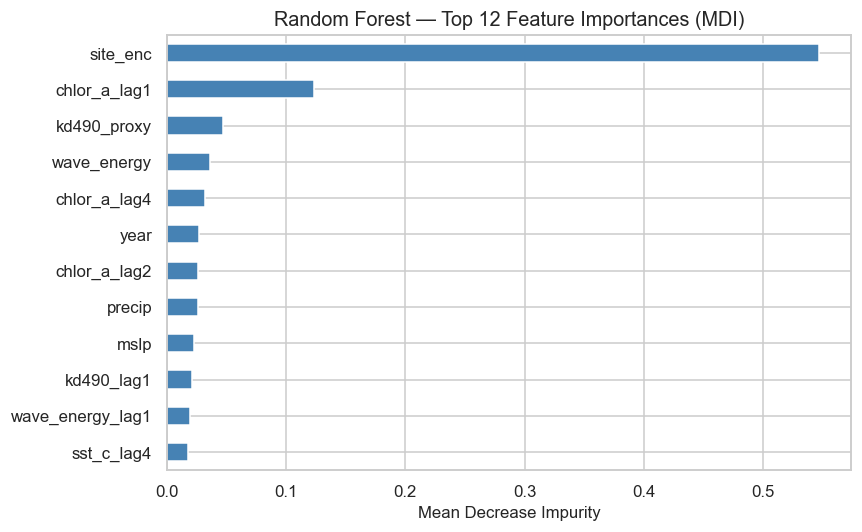

In [7]:
## ── Cell 7: Baseline — Random Forest ─────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

metrics_all.append(
    evaluate("Random Forest", y_test.values, rf_pred,
             label_col=test["label"].values,
             labels=test["label"].unique())
)

# Feature importance (MDI)
rf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
rf_imp.head(12).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Random Forest — Top 12 Feature Importances (MDI)")
ax.set_xlabel("Mean Decrease Impurity")
plt.tight_layout()
plt.savefig(OUT / "rf_feature_importance.png", dpi=120)
plt.show()

In [8]:
## ── Cell 8: Primary model — XGBoost with time-series CV ─────────────────────
from sklearn.model_selection import TimeSeriesSplit

# ── Hyper-parameters (tuned for weekly reef timeseries) ──────────────────────
xgb_params = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric="rmse",
)

# Walk-forward CV on training set — 5 folds
tscv = TimeSeriesSplit(n_splits=5)
cv_rmse = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    m = xgb.XGBRegressor(**xgb_params)
    m.fit(Xtr, ytr,
          eval_set=[(Xval, yval)],
          verbose=False)
    pred  = m.predict(Xval)
    rmse  = np.sqrt(mean_squared_error(yval, pred))
    cv_rmse.append(rmse)
    print(f"  Fold {fold+1}: RMSE={rmse:.4f}  best_iter={m.best_iteration}")

print(f"\nCV RMSE  mean={np.mean(cv_rmse):.4f}  std={np.std(cv_rmse):.4f}")

# ── Retrain on full training set ─────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
xgb_pred = xgb_model.predict(X_test)

metrics_all.append(
    evaluate("XGBoost", y_test.values, xgb_pred,
             label_col=test["label"].values,
             labels=test["label"].unique())
)

  Fold 1: RMSE=0.1773  best_iter=38
  Fold 2: RMSE=0.1372  best_iter=231
  Fold 3: RMSE=0.2652  best_iter=40
  Fold 4: RMSE=0.2282  best_iter=52
  Fold 5: RMSE=0.4125  best_iter=46

CV RMSE  mean=0.2441  std=0.0948

 XGBoost
  Overall → RMSE=0.1835  MAE=0.1301  R²=0.5792
  Havelock       → RMSE=0.1387  MAE=0.1070  R²=0.2135
  Neil           → RMSE=0.1374  MAE=0.0976  R²=0.1799
  Port_Blair     → RMSE=0.1784  MAE=0.1368  R²=0.1015
  Wandoor        → RMSE=0.4216  MAE=0.3561  R²=-0.2301


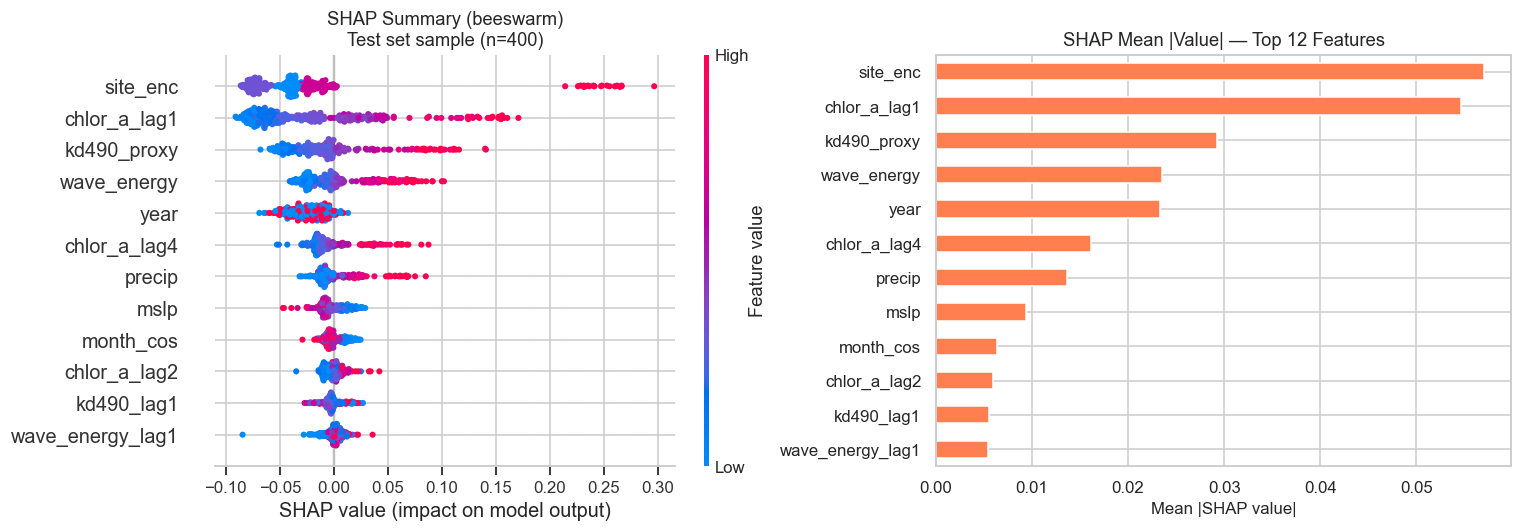

SHAP plot saved.


site_enc            0.057038
chlor_a_lag1        0.054667
kd490_proxy         0.029281
wave_energy         0.023530
year                0.023360
chlor_a_lag4        0.016153
precip              0.013615
mslp                0.009433
month_cos           0.006390
chlor_a_lag2        0.005942
kd490_lag1          0.005519
wave_energy_lag1    0.005450
dtype: float32

In [9]:
## ── Cell 9: SHAP feature importance (XGBoost) ───────────────────────────────
explainer = shap.TreeExplainer(xgb_model)
# Use a stratified subsample to keep it fast (~400 rows)
sample_idx = test.sample(min(400, len(test)), random_state=42).index
X_shap = X_test.loc[sample_idx]

shap_values = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── SHAP summary (beeswarm) ───────────────────────────────────────────────────
plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS,
                  show=False, max_display=12, plot_size=None)
axes[0].set_title("SHAP Summary (beeswarm)\nTest set sample (n=400)", fontsize=12)

# ── SHAP mean |value| bar chart ──────────────────────────────────────────────
shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0), index=FEATURE_COLS
).sort_values(ascending=False)

shap_mean.head(12).plot(kind="barh", ax=axes[1], color="coral")
axes[1].invert_yaxis()
axes[1].set_title("SHAP Mean |Value| — Top 12 Features", fontsize=12)
axes[1].set_xlabel("Mean |SHAP value|")

plt.tight_layout()
plt.savefig(OUT / "xgb_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("SHAP plot saved.")
shap_mean.head(12)

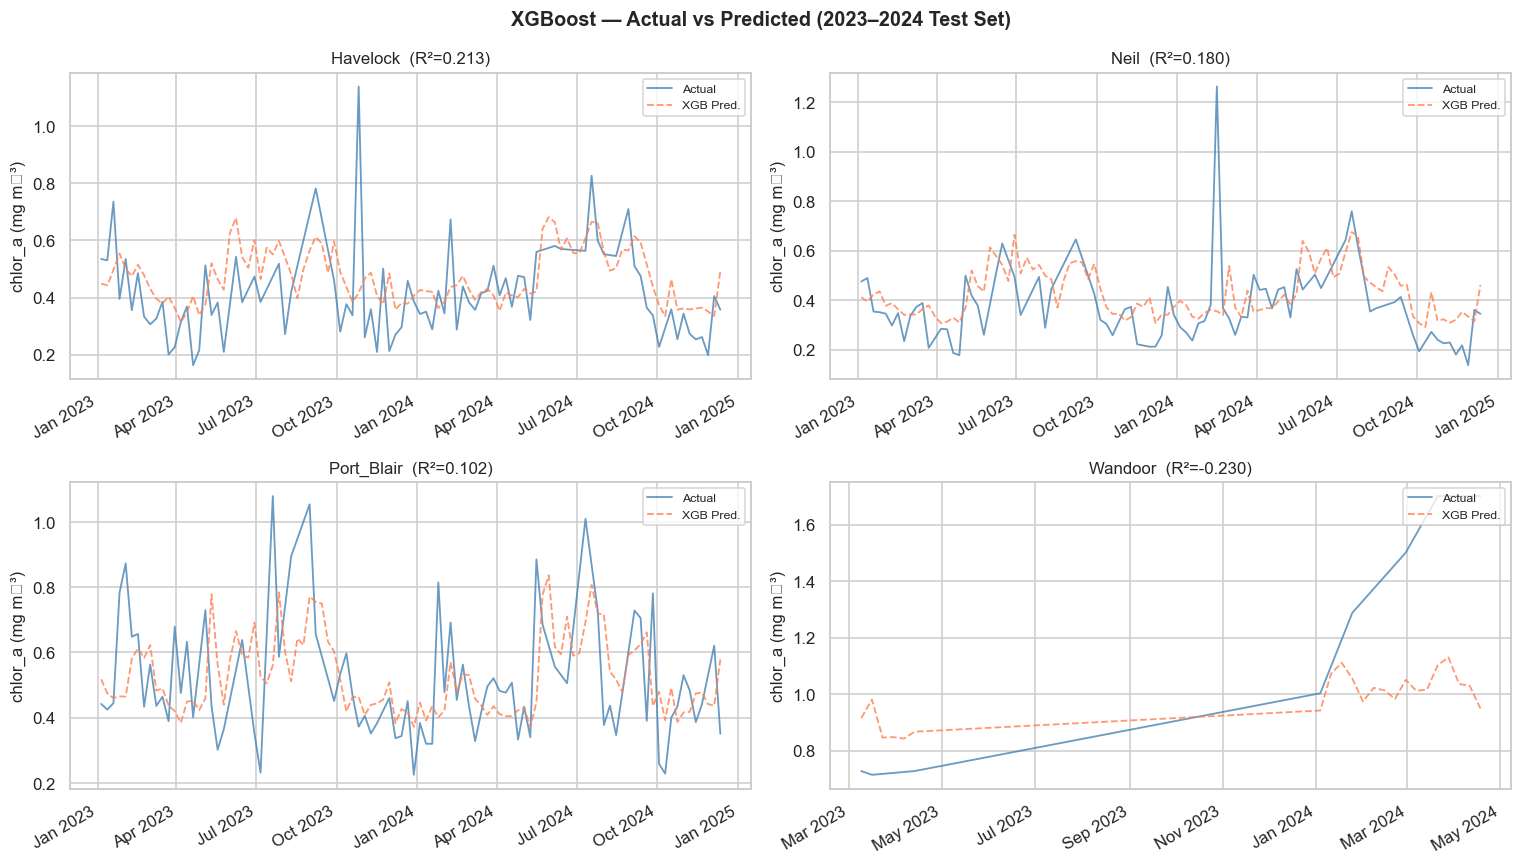

In [10]:
## ── Cell 10: Actual vs Predicted — per site (test set) ──────────────────────
sites = sorted(test["label"].unique())
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

for ax, site in zip(axes.flat, sites):
    mask = test["label"] == site
    dates_s  = test.loc[mask, "date"].values
    actual_s = y_test[mask].values
    pred_s   = xgb_pred[mask.values]

    ax.plot(dates_s, actual_s, label="Actual",    lw=1.2, alpha=0.8, color="steelblue")
    ax.plot(dates_s, pred_s,   label="XGB Pred.", lw=1.2, alpha=0.8, color="coral", ls="--")
    r2_s = r2_score(actual_s, pred_s)
    ax.set_title(f"{site}  (R²={r2_s:.3f})", fontsize=11)
    ax.set_ylabel("chlor_a (mg m⁻³)")
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

fig.suptitle("XGBoost — Actual vs Predicted (2023–2024 Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "xgb_actual_vs_pred.png", dpi=120, bbox_inches="tight")
plt.show()

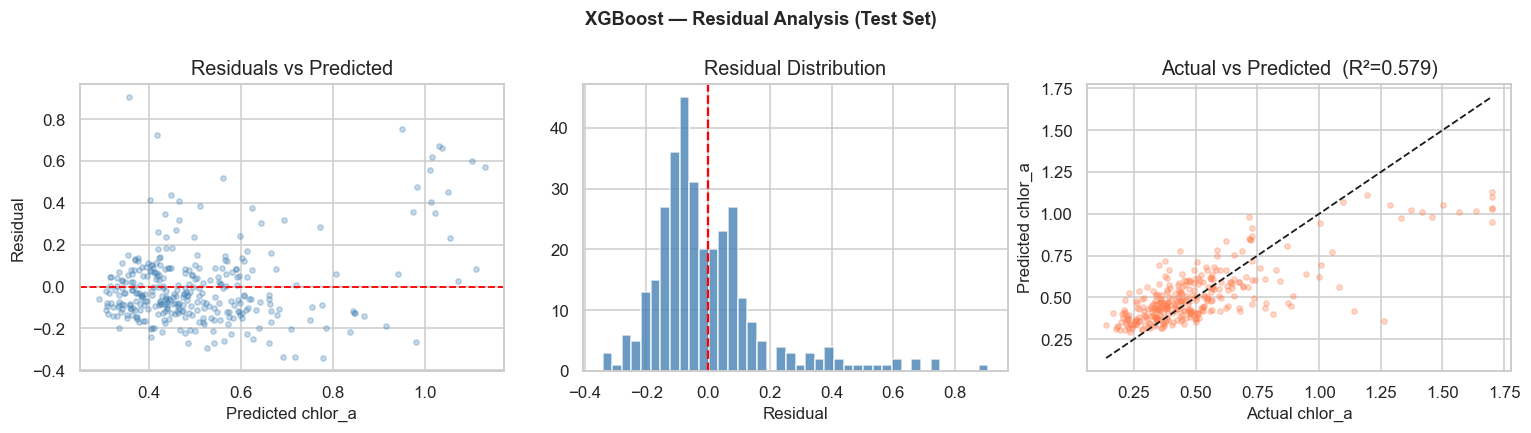

In [11]:
## ── Cell 11: Residual analysis ───────────────────────────────────────────────
residuals = y_test.values - xgb_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Residual vs Predicted
axes[0].scatter(xgb_pred, residuals, alpha=0.3, s=12, color="steelblue")
axes[0].axhline(0, color="red", lw=1.2, ls="--")
axes[0].set_xlabel("Predicted chlor_a")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

# Residual histogram
axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", lw=1.5, ls="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

# Actual vs Predicted scatter
axes[2].scatter(y_test, xgb_pred, alpha=0.3, s=12, color="coral")
lims = [min(y_test.min(), xgb_pred.min()), max(y_test.max(), xgb_pred.max())]
axes[2].plot(lims, lims, "k--", lw=1.2)
axes[2].set_xlabel("Actual chlor_a")
axes[2].set_ylabel("Predicted chlor_a")
axes[2].set_title(f"Actual vs Predicted  (R²={r2_score(y_test, xgb_pred):.3f})")

plt.suptitle("XGBoost — Residual Analysis (Test Set)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "xgb_residuals.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
## ── Cell 12: Final metrics summary table ─────────────────────────────────────
metrics_df = pd.concat(metrics_all, ignore_index=True)

# Overall comparison table
overall = metrics_df[metrics_df["Site"] == "ALL"][["Model", "RMSE", "MAE", "R2"]]
print("═" * 46)
print("  Model Comparison — Test Set (2023–2024)")
print("═" * 46)
print(overall.to_string(index=False))
print()

# Per-site XGBoost table
per_site = metrics_df[(metrics_df["Model"] == "XGBoost") & (metrics_df["Site"] != "ALL")]
print("  XGBoost — Per-Site Metrics")
print("─" * 46)
print(per_site[["Site", "RMSE", "MAE", "R2"]].to_string(index=False))

# Save metrics CSV for report
metrics_df.to_csv(OUT / "task1_metrics.csv", index=False)
print(f"\nMetrics saved → {OUT / 'task1_metrics.csv'}")

# Save model
xgb_model.save_model(str(OUT / "xgb_task1.json"))
print(f"Model saved  → {OUT / 'xgb_task1.json'}")

══════════════════════════════════════════════
  Model Comparison — Test Set (2023–2024)
══════════════════════════════════════════════
        Model     RMSE      MAE       R2
Random Forest 0.173140 0.126559 0.625331
      XGBoost 0.183499 0.130057 0.579157

  XGBoost — Per-Site Metrics
──────────────────────────────────────────────
      Site     RMSE      MAE        R2
  Havelock 0.138651 0.107013  0.213490
      Neil 0.137450 0.097606  0.179880
Port_Blair 0.178418 0.136801  0.101515
   Wandoor 0.421553 0.356083 -0.230132

Metrics saved → C:\Users\mudit\OneDrive\Desktop\Fourth Sem\Independent Study\outputs\task1\task1_metrics.csv
Model saved  → C:\Users\mudit\OneDrive\Desktop\Fourth Sem\Independent Study\outputs\task1\xgb_task1.json


In [13]:
## ── Cell 13: Per-site XGBoost models (fix for misleading pooled R²) ──────────
# Remove site_enc — each model sees only ONE site's data, so identity is implicit.
FEAT_SITE = [f for f in FEATURE_COLS if f != "site_enc"]

xgb_params_site = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,          # shallower → less overfit on small per-site data
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=1.5,
    min_child_weight=5,   # larger → more conservative splits
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric="rmse",
)

site_models   = {}
site_metrics  = []
site_preds    = {}   # store for plotting

for site in sorted(model_df["label"].unique()):
    tr_s = train[train["label"] == site]
    te_s = test[test["label"] == site]

    Xtr_s, ytr_s = tr_s[FEAT_SITE], tr_s[TARGET_COL]
    Xte_s, yte_s = te_s[FEAT_SITE], te_s[TARGET_COL]

    m = xgb.XGBRegressor(**xgb_params_site)
    m.fit(Xtr_s, ytr_s, eval_set=[(Xte_s, yte_s)], verbose=False)

    pred = m.predict(Xte_s)
    site_models[site]  = m
    site_preds[site]   = (te_s["date"].values, yte_s.values, pred)

    rmse = np.sqrt(mean_squared_error(yte_s, pred))
    mae  = mean_absolute_error(yte_s, pred)
    r2   = r2_score(yte_s, pred)
    site_metrics.append({"Site": site, "RMSE": rmse, "MAE": mae, "R2": r2,
                          "Train_rows": len(tr_s), "Test_rows": len(te_s)})
    print(f"  {site:<14} → RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  "
          f"(train={len(tr_s)}, test={len(te_s)})")

site_df = pd.DataFrame(site_metrics)
avg_r2  = site_df["R2"].mean()
print(f"\n  Mean per-site R² = {avg_r2:.4f}  (pooled XGB was 0.5792)")

# ── Side-by-side comparison ──────────────────────────────────────────────────
print("\n  Comparison — Pooled XGB  vs  Per-Site XGB")
print("  " + "─"*54)
print(f"  {'Site':<14} {'Pooled R²':>10}  {'Per-Site R²':>12}  {'Change':>8}")
print("  " + "─"*54)
pooled_lookup = {
    "Havelock":  0.213, "Neil": 0.180,
    "Port_Blair": 0.102, "Wandoor": -0.230
}
for row in site_metrics:
    s = row["Site"]
    pool_r2 = pooled_lookup.get(s, float("nan"))
    delta   = row["R2"] - pool_r2
    arrow   = "↑" if delta > 0 else "↓"
    print(f"  {s:<14} {pool_r2:>10.3f}  {row['R2']:>12.3f}  {arrow}{abs(delta):.3f}")


  Havelock       → RMSE=0.1446  MAE=0.1097  R²=0.1450  (train=930, test=102)
  Neil           → RMSE=0.1315  MAE=0.0905  R²=0.2493  (train=941, test=102)
  Port_Blair     → RMSE=0.1709  MAE=0.1343  R²=0.1754  (train=892, test=102)
  Wandoor        → RMSE=0.3800  MAE=0.3400  R²=0.0002  (train=411, test=22)

  Mean per-site R² = 0.1425  (pooled XGB was 0.5792)

  Comparison — Pooled XGB  vs  Per-Site XGB
  ──────────────────────────────────────────────────────
  Site            Pooled R²   Per-Site R²    Change
  ──────────────────────────────────────────────────────
  Havelock            0.213         0.145  ↓0.068
  Neil                0.180         0.249  ↑0.069
  Port_Blair          0.102         0.175  ↑0.073
  Wandoor            -0.230         0.000  ↑0.230


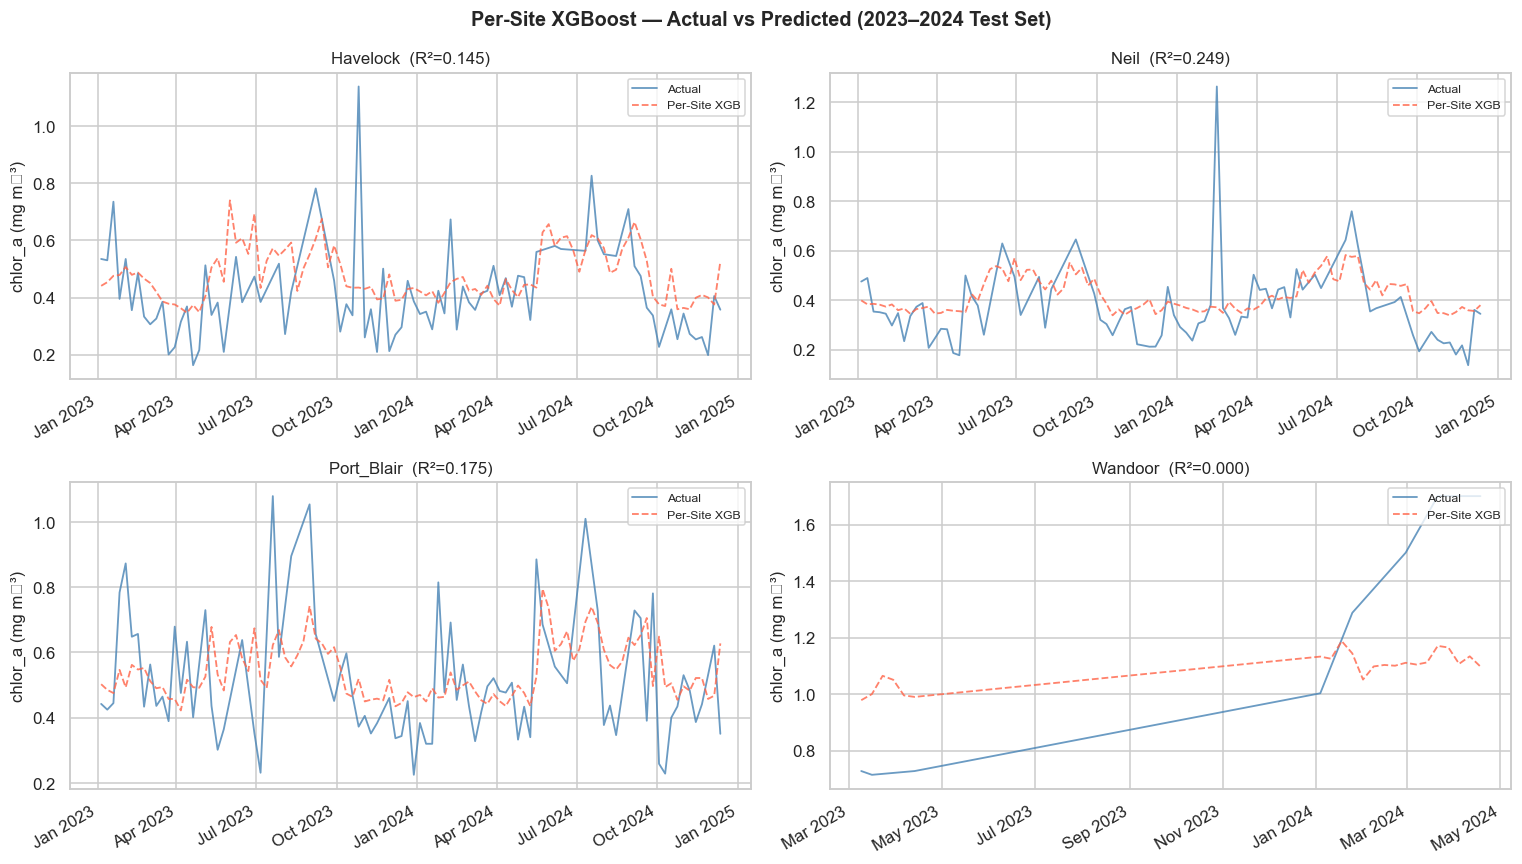

Saved → C:\Users\mudit\OneDrive\Desktop\Fourth Sem\Independent Study\outputs\task1\task1_persite_metrics.csv


In [14]:
## ── Cell 14: Per-site actual vs predicted plot ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

for ax, site in zip(axes.flat, sorted(site_preds)):
    dates_s, actual_s, pred_s = site_preds[site]
    r2_s = r2_score(actual_s, pred_s)

    ax.plot(dates_s, actual_s, label="Actual",        lw=1.2, alpha=0.8, color="steelblue")
    ax.plot(dates_s, pred_s,   label="Per-Site XGB",  lw=1.2, alpha=0.8, color="tomato", ls="--")
    ax.set_title(f"{site}  (R²={r2_s:.3f})", fontsize=11)
    ax.set_ylabel("chlor_a (mg m⁻³)")
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

fig.suptitle("Per-Site XGBoost — Actual vs Predicted (2023–2024 Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "xgb_persite_actual_vs_pred.png", dpi=120, bbox_inches="tight")
plt.show()

# Save per-site metrics
site_df.to_csv(OUT / "task1_persite_metrics.csv", index=False)
print(f"Saved → {OUT / 'task1_persite_metrics.csv'}")


In [15]:
## ── Cell 15: Persistence baseline — naive "next week = this week" ─────────────
# For each site: predicted chlor_a(t+1) = actual chlor_a(t)  i.e. chlor_a_lag1
persistence_rows = []
print("  Persistence Baseline  vs  Per-Site XGBoost  (test set)")
print("  " + "─" * 60)
print(f"  {'Site':<14} {'Persist RMSE':>13} {'Persist R²':>11}  |  "
      f"{'XGB RMSE':>9} {'XGB R²':>8}  {'Skill':>8}")
print("  " + "─" * 60)

for site in sorted(site_preds):
    dates_s, actual_s, xgb_pred_s = site_preds[site]

    # Persistence prediction = lag-1 value from test set
    te_s   = test[test["label"] == site].copy()
    persist_pred = te_s["chlor_a_lag1"].values     # already in model_df

    # Align lengths (target may differ by 1 from lag)
    min_len = min(len(actual_s), len(persist_pred))
    act     = actual_s[:min_len]
    pp      = persist_pred[:min_len]
    xp      = xgb_pred_s[:min_len]

    p_rmse = np.sqrt(mean_squared_error(act, pp))
    p_r2   = r2_score(act, pp)
    x_rmse = np.sqrt(mean_squared_error(act, xp))
    x_r2   = r2_score(act, xp)

    # Skill score: how much XGB beats persistence (positive = improvement)
    skill = x_r2 - p_r2

    arrow = "↑" if skill > 0 else "↓"
    print(f"  {site:<14} {p_rmse:>13.4f} {p_r2:>11.3f}  |  "
          f"{x_rmse:>9.4f} {x_r2:>8.3f}  {arrow}{abs(skill):.3f}")

    persistence_rows.append({
        "Site": site,
        "Persist_RMSE": p_rmse, "Persist_R2": p_r2,
        "XGB_RMSE":     x_rmse, "XGB_R2":     x_r2,
        "Skill_gain":   skill,
    })

persist_df = pd.DataFrame(persistence_rows)
print(f"\n  Mean persistence R²  = {persist_df['Persist_R2'].mean():.3f}")
print(f"  Mean per-site XGB R² = {persist_df['XGB_R2'].mean():.3f}")
print(f"  Mean skill gain      = {persist_df['Skill_gain'].mean():.3f}")
persist_df.to_csv(OUT / "task1_persistence_baseline.csv", index=False)


  Persistence Baseline  vs  Per-Site XGBoost  (test set)
  ────────────────────────────────────────────────────────────
  Site            Persist RMSE  Persist R²  |   XGB RMSE   XGB R²     Skill
  ────────────────────────────────────────────────────────────
  Havelock              0.1720      -0.210  |     0.1446    0.145  ↑0.355
  Neil                  0.1768      -0.356  |     0.1315    0.249  ↑0.606
  Port_Blair            0.2209      -0.377  |     0.1709    0.175  ↑0.552
  Wandoor               0.1057       0.923  |     0.3800    0.000  ↓0.922

  Mean persistence R²  = -0.005
  Mean per-site XGB R² = 0.142
  Mean skill gain      = 0.148


  Log-transform XGBoost  vs  Linear-target XGBoost  (per-site test set)
  ──────────────────────────────────────────────────────────────
  Site             Log R²   Linear R²    Change
  ──────────────────────────────────────────────────────────────
  Havelock          0.229       0.145  ↑0.084
  Neil              0.250       0.249  ↑0.001
  Port_Blair        0.152       0.175  ↓0.023
  Wandoor          -0.009       0.000  ↓0.010

  Mean  log R² = 0.156  (linear was 0.142  |  persistence was -0.005)


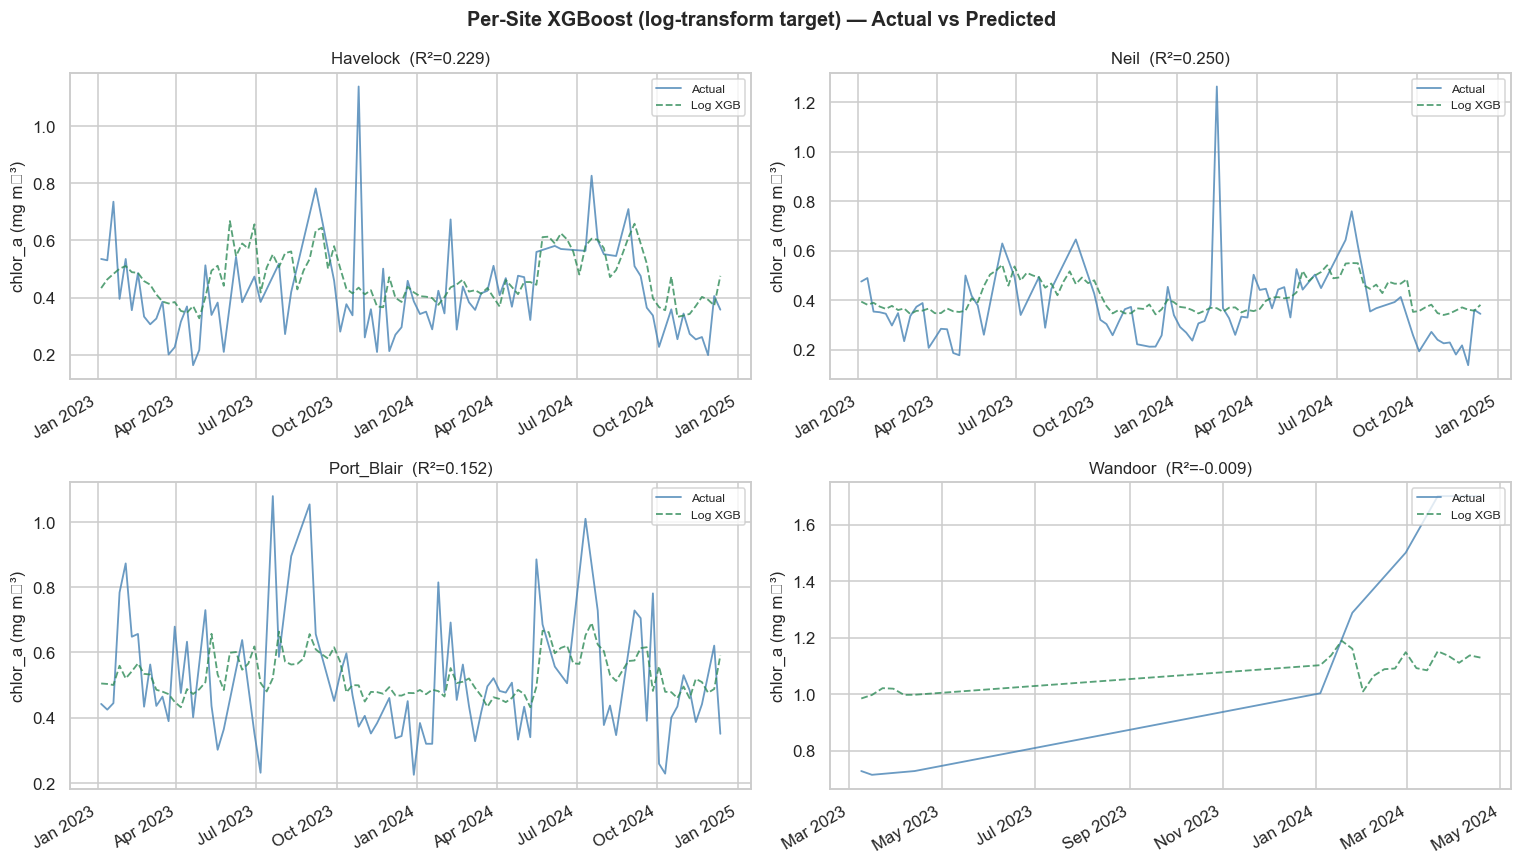


Saved → C:\Users\mudit\OneDrive\Desktop\Fourth Sem\Independent Study\outputs\task1\task1_log_metrics.csv


In [16]:
## ── Cell 16: Log-transform target — per-site XGBoost (improved model) ────────
import warnings
warnings.filterwarnings("ignore")

log_rows  = []
log_preds = {}

for site in sorted(model_df["label"].unique()):
    tr_s = train[train["label"] == site].copy()
    te_s = test[test["label"] == site].copy()

    Xtr_s = tr_s[FEAT_SITE]
    Xte_s = te_s[FEAT_SITE]

    # Log-transform target; clip to avoid log(0)
    ytr_log = np.log1p(tr_s[TARGET_COL].clip(lower=0))
    yte_raw = te_s[TARGET_COL].values

    m_log = xgb.XGBRegressor(**xgb_params_site)
    m_log.fit(Xtr_s, ytr_log,
              eval_set=[(Xte_s, np.log1p(te_s[TARGET_COL].clip(lower=0)))],
              verbose=False)

    # Predict in log-space then back-transform
    pred_log = m_log.predict(Xte_s)
    pred_raw = np.expm1(pred_log).clip(min=0)

    rmse = np.sqrt(mean_squared_error(yte_raw, pred_raw))
    mae  = mean_absolute_error(yte_raw, pred_raw)
    r2   = r2_score(yte_raw, pred_raw)
    log_rows.append({"Site": site, "RMSE": rmse, "MAE": mae, "R2": r2})
    log_preds[site] = (te_s["date"].values, yte_raw, pred_raw)

log_df = pd.DataFrame(log_rows)

# ── Summary comparison ────────────────────────────────────────────────────────
print("  Log-transform XGBoost  vs  Linear-target XGBoost  (per-site test set)")
print("  " + "─" * 62)
print(f"  {'Site':<14} {'Log R²':>8}  {'Linear R²':>10}  {'Change':>8}")
print("  " + "─" * 62)
linear_r2 = dict(zip(site_df["Site"], site_df["R2"]))
for row in log_rows:
    s   = row["Site"]
    lin = linear_r2.get(s, float("nan"))
    delta = row["R2"] - lin
    arrow = "↑" if delta > 0 else "↓"
    print(f"  {s:<14} {row['R2']:>8.3f}  {lin:>10.3f}  {arrow}{abs(delta):.3f}")

print(f"\n  Mean  log R² = {log_df['R2'].mean():.3f}  "
      f"(linear was {site_df['R2'].mean():.3f}  |  "
      f"persistence was {persist_df['Persist_R2'].mean():.3f})")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
for ax, site in zip(axes.flat, sorted(log_preds)):
    dates_s, actual_s, pred_s = log_preds[site]
    r2_s = r2_score(actual_s, pred_s)
    ax.plot(dates_s, actual_s, lw=1.2, alpha=0.8, color="steelblue", label="Actual")
    ax.plot(dates_s, pred_s,   lw=1.2, alpha=0.8, color="seagreen",  label="Log XGB", ls="--")
    ax.set_title(f"{site}  (R²={r2_s:.3f})", fontsize=11)
    ax.set_ylabel("chlor_a (mg m⁻³)")
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

fig.suptitle("Per-Site XGBoost (log-transform target) — Actual vs Predicted",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "xgb_log_actual_vs_pred.png", dpi=120, bbox_inches="tight")
plt.show()

log_df.to_csv(OUT / "task1_log_metrics.csv", index=False)
print(f"\nSaved → {OUT / 'task1_log_metrics.csv'}")
